In [17]:
from google.cloud import bigquery

import numpy as np

import matplotlib.pyplot as plt
import igraph as ig

In [3]:
client = bigquery.Client(project='gcp-cset-projects')

In [7]:
cluster_query = """
SELECT
  *
FROM staging_patent_clusters.cluster_ranked_connections
WHERE link_rank < 11
"""

In [8]:
result = client.query(cluster_query)

In [9]:
cluster_citations = []
for row in result:
    temp_dict = {'cluster_id':row['family_cluster'],'ref_id':row['ref_cluster'],'weight':row['weight']}
    cluster_citations.append(temp_dict)

In [14]:
citation_edges = [[row['cluster_id'], row['ref_id']] for row in cluster_citations]
g_citations = ig.Graph(edges = citation_edges,
                       edge_attrs = {'weights':[row['weight'] for row in cluster_citations]})

In [15]:
layout = g_citations.layout(layout='auto', weights='weights')

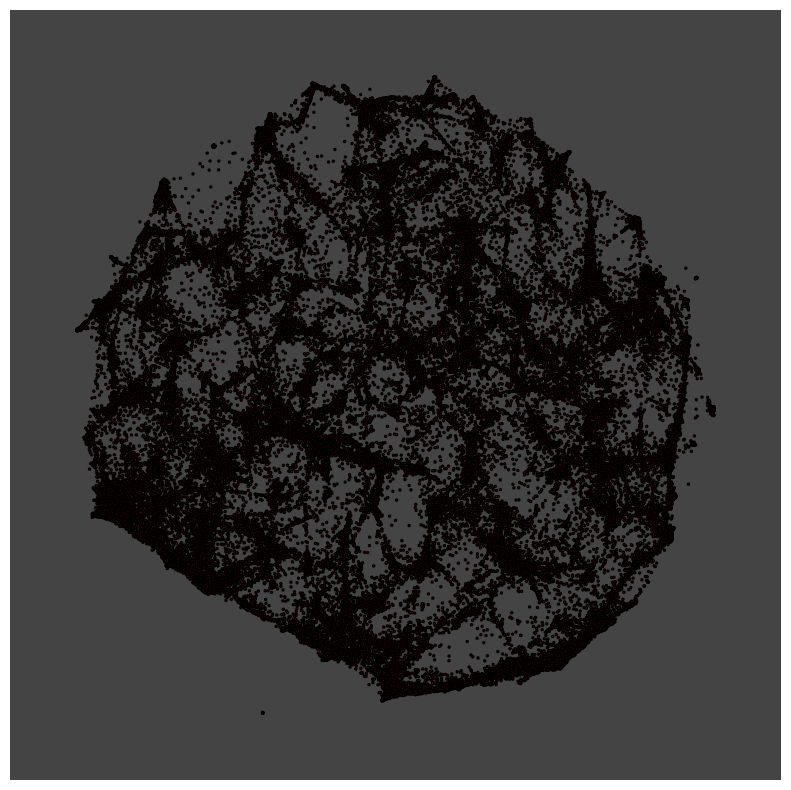

In [18]:
fig, ax = plt.subplots(figsize=(10,10))
ig.plot(g_citations, layout=layout, target=ax, edge_width=g_citations.es['weights'], vertex_size=2)
ax.set_aspect('equal')
plt.show()